In [4]:
#%% PACKAGES
# Basics
import numpy as np                                                          
from math import pi                                                            
import warnings                                                              
import os    

from datetime import datetime, timedelta
from pandas import DataFrame
import geopandas as gpd

from sklearn.preprocessing import MinMaxScaler

# Visualization
import pandas as pd                                                          
import matplotlib.pyplot as plt                                                
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

import numpy as np
import seaborn as sns; sns.set_theme(style='white')
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from matplotlib.ticker import MaxNLocator

In [5]:
operation_crs = "EPSG:2056"  # Swiss coordinate system
target_crs = "EPSG:4326"  # WGS84 coordinate system

input_file_path = '../../Data/input/attributs'
output_step1_path='../../Data/output/step-1'
output_step2_path='../../Data/output/step-2'
output_step3_path='../../Data/output/step-3'

#Read the files
IndexRaw = gpd.read_parquet(f'{output_step2_path}/step2_features.parquet')

attributs_info = pd.read_excel(f"{input_file_path}/attributs_info.xlsx", sheet_name="attributs_info")

In [6]:
attributs_info

,Class,meta_attribute,attribute,include_in_index,attribute_source_path,initial_weight,impact_attribut,proportional_weight_col_dtype,file_name,geometry_type,method,method_desc,how,value_column,buffer_size,filter_column,filter_values,crs,save_format
0,Agrément,vegetation,arbre_isole,True,arbre_isole,0.5,favorable,float,SIPV_ICA_ARBRE_ISOLE-SHP/SIPV_ICA_ARBRE_ISOLE.shp,point,A,Buffer du segment,sum,D_COURONNE,10,filtered,1,2056,parquet
1,Agrément,vegetation,espace_vert,True,domaine_routier,0.5,favorable,NaN,CAD_DOMAINE_ROUTIER-SHP/CAD_DOMAINE_ROUTIER.shp,polygon,A,Buffer du segment,area_ratio,NaN,10,filtered,1,2056,parquet
2,Sécurité,accident,accident,True,accident,0.3,defavorable,NaN,OTC_ACCIDENTS-SHP/OTC_ACCIDENTS.shp,point,A,Buffer du segment,count,NaN,10,filtered,1,2056,parquet
3,NaN,toilette,toilette,False,NaN,0.5,favorable,NaN,VDG_WC_PUBLIC-SHP/VDG_WC_PUBLIC.shp,point,A,Buffer du segment,count,NaN,10,filtered,1,2056,parquet
4,Sécurité,traffic,zone_apaisee,True,vitesse,0.5,favorable,NaN,OTC_LIMITATIONS_VITESSE-SHP/OTC_LIMITATIONS_VI...,polygon,A,Buffer du segment,area_ratio,NaN,10,filtered,1,2056,parquet
5,Sécurité,traffic,zone_pietonne,True,vitesse,1.0,favorable,NaN,OTC_ZONE_MODERATION_TRAFIC-SHP/OTC_ZONE_MODERA...,polygon,A,Buffer du segment,area_ratio,NaN,10,filtered,1,2056,parquet
6,Sécurité,traffic,vitesse,True,vitesse,0.6,defavorable,NaN,OTC_LIMITATIONS_VITESSE-SHP/OTC_LIMITATIONS_VI...,polygon,A,Buffer du segment,area_ratio,NaN,10,filtered,1,2056,parquet
7,Sécurité,largeur trottoir,ratio_trottoir,True,domaine_routier,0.5,favorable,float,CAD_DOMAINE_ROUTIER-SHP/CAD_DOMAINE_ROUTIER.shp,polygon,A,Buffer du segment,area_ratio,NaN,10,filtered,1,2056,parquet
8,NaN,eau,eau,False,NaN,0.5,favorable,NaN,LCE_GRAPHE_EAU-SHP/LCE_GRAPHE_EAU.shp,line,A,Buffer du segment,count,NaN,10,filtered,1,2056,parquet
9,Attractivité,proximite,rez_actif,True,rez_actif,0.5,favorable,NaN,REG_ENTREPRISE_ETABLISSEMENT-SHP/REG_ENTREPRIS...,point,A,Buffer du segment,count,NaN,10,filtered,1,2056,parquet


In [7]:
print(attributs_info['attribute'].to_list())

['arbre_isole', 'espace_vert', 'accident', 'toilette', 'zone_apaisee', 'zone_pietonne', 'vitesse', 'ratio_trottoir', 'eau', 'rez_actif', 'objets_divers', 'stationnement_genant', 'bruit', 'tp', 'amenite', 'espaces_ouverts', 'temperature']


In [8]:
#Delete where includes in index = False
attributs_info = attributs_info[attributs_info['include_in_index'] != False]

In [9]:
# Fill NULL
Indexv1 = IndexRaw.fillna(0)

# Create mapping for processed columns while keeping first 5 columns unchanged
attribute_mapping = {}
for _, row in attributs_info.iterrows():
    old_name = f"{row['attribute']}_{row['method']}_{row['buffer_size']}"
    new_name = row['attribute']
    attribute_mapping[old_name] = new_name

# Keep first 5 columns as is, rename the rest using the mapping
first_5_cols = IndexRaw.columns[:5].tolist()
Indexv1 = Indexv1.rename(columns=attribute_mapping)

# Debug info
print("First 5 columns:", first_5_cols)
print("Renamed columns:", [col for col in Indexv1.columns if col not in first_5_cols])

Indexv1

First 5 columns: ['osmid', 'maxspeed', 'geometry', 'segment_id', 'length']
Renamed columns: ['arbre_isole', 'espace_vert', 'accident', 'zone_apaisee', 'zone_pietonne', 'vitesse', 'ratio_trottoir', 'rez_actif', 'stationnement_genant', 'bruit', 'tp', 'amenite', 'espaces_ouverts', 'temperature']


,osmid,maxspeed,geometry,segment_id,length,arbre_isole,espace_vert,accident,zone_apaisee,zone_pietonne,vitesse,ratio_trottoir,rez_actif,stationnement_genant,bruit,tp,amenite,espaces_ouverts,temperature
0,680474053,0,"LINESTRING (6.16301 46.20775, 6.16304 46.20769)",680474053_001,7.236785,0.0,0.083783,2.0,1.831794,0.0,1.831794,0.240748,0.0,12.0,0.0,0.0,0.0,0.0,30.375301
1,680474053,0,"LINESTRING (6.16301 46.20775, 6.16297 46.20784)",680474053_002,10.533514,0.0,0.005835,2.0,2.414139,0.0,2.414139,0.538427,0.0,1.0,0.0,0.0,0.0,1.0,31.703800
2,678844695,0,"LINESTRING (6.17218 46.21164, 6.17225 46.21157)",678844695_001,9.102543,12.0,0.059789,0.0,3.099900,0.0,3.099900,0.208070,0.0,0.0,0.0,1.0,0.0,1.0,0.000000
3,678844695,0,"LINESTRING (6.17218 46.21164, 6.1721 46.21173)",678844695_002,11.727643,10.0,0.091713,1.0,1.939113,0.0,1.939113,0.644849,0.0,0.0,0.0,0.0,0.0,1.0,29.021099
4,357504864,0,"LINESTRING (6.18037 46.22137, 6.18029 46.2214)",357504864_001,6.640850,8.0,0.017871,4.0,5.044367,0.0,5.044367,0.141975,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158861,792218731,0,"LINESTRING (6.12393 46.21488, 6.12402 46.21497)",792218731_047,11.613824,36.0,0.082600,1.0,2.900409,0.0,0.725102,0.739258,0.0,0.0,0.0,0.0,0.0,1.0,29.433701
158862,792218731,0,"LINESTRING (6.12393 46.21488, 6.12368 46.21464...",792218731_048,39.705024,66.0,0.000000,1.0,3.644037,0.0,0.712695,0.672358,0.0,0.0,0.0,0.0,0.0,1.0,30.472950
158863,1412796425,0,"LINESTRING (6.17347 46.21472, 6.1736 46.21457,...",1412796425_002,25.548141,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,23.535500
158864,1413297772,0,"LINESTRING (6.11302 46.23364, 6.11302 46.23365)",1413297772_006,1.428117,0.0,0.000000,0.0,7.477224,0.0,7.477224,0.156220,0.0,0.0,1.0,0.0,0.0,0.0,0.000000


In [10]:
print('Crop outliers if necessary: --> see Walkability Amsterdam notebook')
Indexv2 = Indexv1.copy()
#Adding intervals (for factors where we have an interval of interest and below or above that interval the situation doesn't affect the walkability)

#Indexv2['stationnement_genant'] = Indexv1['stationnement_genant'].clip(upper=5) #more than 20 stationnement_genant in 10-meters-radius around segment centroid


#Remove segments of less than 1m length
'''print("Keep only segment > 1 meter")
length_min = 1
Indexv2 = Indexv1[Indexv1['length'] > length_min]'''


Crop outliers if necessary: --> see Walkability Amsterdam notebook


'print("Keep only segment > 1 meter")\nlength_min = 1\nIndexv2 = Indexv1[Indexv1[\'length\'] > length_min]'

In [11]:
attributs_info

,Class,meta_attribute,attribute,include_in_index,attribute_source_path,initial_weight,impact_attribut,proportional_weight_col_dtype,file_name,geometry_type,method,method_desc,how,value_column,buffer_size,filter_column,filter_values,crs,save_format
0,Agrément,vegetation,arbre_isole,True,arbre_isole,0.5,favorable,float,SIPV_ICA_ARBRE_ISOLE-SHP/SIPV_ICA_ARBRE_ISOLE.shp,point,A,Buffer du segment,sum,D_COURONNE,10,filtered,1,2056,parquet
1,Agrément,vegetation,espace_vert,True,domaine_routier,0.5,favorable,NaN,CAD_DOMAINE_ROUTIER-SHP/CAD_DOMAINE_ROUTIER.shp,polygon,A,Buffer du segment,area_ratio,NaN,10,filtered,1,2056,parquet
2,Sécurité,accident,accident,True,accident,0.3,defavorable,NaN,OTC_ACCIDENTS-SHP/OTC_ACCIDENTS.shp,point,A,Buffer du segment,count,NaN,10,filtered,1,2056,parquet
4,Sécurité,traffic,zone_apaisee,True,vitesse,0.5,favorable,NaN,OTC_LIMITATIONS_VITESSE-SHP/OTC_LIMITATIONS_VI...,polygon,A,Buffer du segment,area_ratio,NaN,10,filtered,1,2056,parquet
5,Sécurité,traffic,zone_pietonne,True,vitesse,1.0,favorable,NaN,OTC_ZONE_MODERATION_TRAFIC-SHP/OTC_ZONE_MODERA...,polygon,A,Buffer du segment,area_ratio,NaN,10,filtered,1,2056,parquet
6,Sécurité,traffic,vitesse,True,vitesse,0.6,defavorable,NaN,OTC_LIMITATIONS_VITESSE-SHP/OTC_LIMITATIONS_VI...,polygon,A,Buffer du segment,area_ratio,NaN,10,filtered,1,2056,parquet
7,Sécurité,largeur trottoir,ratio_trottoir,True,domaine_routier,0.5,favorable,float,CAD_DOMAINE_ROUTIER-SHP/CAD_DOMAINE_ROUTIER.shp,polygon,A,Buffer du segment,area_ratio,NaN,10,filtered,1,2056,parquet
9,Attractivité,proximite,rez_actif,True,rez_actif,0.5,favorable,NaN,REG_ENTREPRISE_ETABLISSEMENT-SHP/REG_ENTREPRIS...,point,A,Buffer du segment,count,NaN,10,filtered,1,2056,parquet
11,infrastructure,stationnement_genant,stationnement_genant,True,stationnement_genant,0.3,defavorable,NaN,SHP_FDP/FDP_STATIONNEMENT_GENANT_PIETON_CONTRA...,point,A,Buffer du segment,count,NaN,10,filtered,1,2056,parquet
12,Agrément,bruit,bruit,True,bruit,0.3,defavorable,NaN,SPBR_BRUIT_ROUTIER_FACADE-SHP/SPBR_BRUIT_ROUTI...,line,A,Buffer du segment,count,NaN,10,filtered,1,2056,parquet


In [12]:
# Create copy and normalize
Indexv3 = Indexv2.copy()
scaler = MinMaxScaler()

# Track changes during normalization
print("Min max normalization...")
for attribute in attributs_info['attribute']:
    if attribute in Indexv3.columns:
        # Normalize
        Indexv3.loc[:, attribute] = scaler.fit_transform(Indexv3[[attribute]]).round(4)
    else:
        print(f"Attribute '{attribute}' not found in Indexv3 columns.")

Min max normalization...


In [13]:
# Inverse columns (for factors that have a negative effect on walkability) depending on attributs_info.impact_attribut (favorable or defavorable)
print("Inverse columns where necessary...")
for _, row in attributs_info.iterrows():
    attribute_name = row['attribute']
    impact = row['impact_attribut']
    if attribute_name in Indexv3.columns:
        if impact == 'defavorable':
            Indexv3[attribute_name] = 1 - Indexv3[attribute_name]
            print(f"Inverted attribute: {attribute_name}")
    else:
        print(f"Attribute '{attribute_name}' not found in Indexv3 columns.")


Inverse columns where necessary...
Inverted attribute: accident
Inverted attribute: vitesse
Inverted attribute: stationnement_genant
Inverted attribute: bruit
Inverted attribute: temperature


In [14]:
Indexv3

,osmid,maxspeed,geometry,segment_id,length,arbre_isole,espace_vert,accident,zone_apaisee,zone_pietonne,vitesse,ratio_trottoir,rez_actif,stationnement_genant,bruit,tp,amenite,espaces_ouverts,temperature
0,680474053,0,"LINESTRING (6.16301 46.20775, 6.16304 46.20769)",680474053_001,7.236785,0.0000,0.0149,0.9231,0.0021,0.0,0.9966,0.0278,0.0,0.9887,1.0000,0.0000,0.0,0.0,0.1177
1,680474053,0,"LINESTRING (6.16301 46.20775, 6.16297 46.20784)",680474053_002,10.533514,0.0000,0.0010,0.9231,0.0028,0.0,0.9955,0.0622,0.0,0.9991,1.0000,0.0000,0.0,0.1,0.0792
2,678844695,0,"LINESTRING (6.17218 46.21164, 6.17225 46.21157)",678844695_001,9.102543,0.0168,0.0106,1.0000,0.0036,0.0,0.9942,0.0240,0.0,1.0000,1.0000,0.3333,0.0,0.1,1.0000
3,678844695,0,"LINESTRING (6.17218 46.21164, 6.1721 46.21173)",678844695_002,11.727643,0.0140,0.0163,0.9615,0.0023,0.0,0.9964,0.0744,0.0,1.0000,1.0000,0.0000,0.0,0.1,0.1571
4,357504864,0,"LINESTRING (6.18037 46.22137, 6.18029 46.2214)",357504864_001,6.640850,0.0112,0.0032,0.8462,0.0059,0.0,0.9905,0.0164,0.0,1.0000,1.0000,0.0000,0.0,0.0,1.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158861,792218731,0,"LINESTRING (6.12393 46.21488, 6.12402 46.21497)",792218731_047,11.613824,0.0503,0.0147,0.9615,0.0034,0.0,0.9986,0.0853,0.0,1.0000,1.0000,0.0000,0.0,0.1,0.1451
158862,792218731,0,"LINESTRING (6.12393 46.21488, 6.12368 46.21464...",792218731_048,39.705024,0.0923,0.0000,0.9615,0.0043,0.0,0.9987,0.0776,0.0,1.0000,1.0000,0.0000,0.0,0.1,0.1149
158863,1412796425,0,"LINESTRING (6.17347 46.21472, 6.1736 46.21457,...",1412796425_002,25.548141,0.0000,0.0000,1.0000,0.0000,0.0,1.0000,0.0000,0.0,1.0000,1.0000,0.0000,0.0,0.0,0.3164
158864,1413297772,0,"LINESTRING (6.11302 46.23364, 6.11302 46.23365)",1413297772_006,1.428117,0.0000,0.0000,1.0000,0.0087,0.0,0.9859,0.0180,0.0,1.0000,0.9167,0.0000,0.0,0.0,1.0000


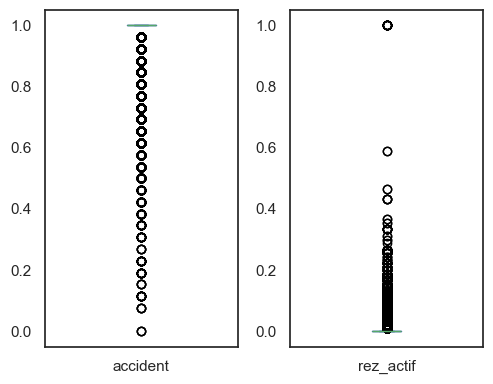

In [15]:
#Check data distribution (use this to check if there are still outliers skewing the factors)

Indexv3[['accident', 'rez_actif']].plot(kind='box', subplots=True, layout=(1, 4), figsize=(10, 4))
plt.tight_layout()
plt.show()


In [16]:
# Calculate the Main Index Scores
Indexv4 = Indexv3

# Get weights from attributs_info and check validity
Zscore_weights = {}
for _, row in attributs_info[attributs_info.include_in_index == True].iterrows():
    attr = row['attribute']
    weight = row['initial_weight']
    if pd.isnull(weight):
        raise ValueError(f"Weight not specified for attribute '{attr}' (found NaN). Please specify a value between 0 and 1.")
    if not (0 <= weight <= 1):
        raise ValueError(f"Weight for attribute '{attr}' is {weight}, but must be between 0 and 1.")
    Zscore_weights[attr] = weight

print("Zscore_weights:", Zscore_weights)


# add zscore weights to the attributes_info dataframe
attributs_info['weights'] = attributs_info['attribute'].map(Zscore_weights)

# Function Sum-product to calculate sub-index score
def calculate_index(df, weights_dict):
    return sum(df[col] * weight for col, weight in weights_dict.items())

Indexv4['I-Zscore'] = calculate_index(Indexv4, Zscore_weights)
Indexv4['I-Zscore_unweighted'] = calculate_index(Indexv4, {key: 1 for key in Zscore_weights.keys()})

#Normalising Index
#Indexv4['Non-Scaled']=Indexv4['I-Zscore'].round(4)
Indexv4[['I-Zscore']] = scaler.fit_transform(Indexv4[['I-Zscore']]).round(4)
Indexv4[['I-Zscore_unweighted']] = scaler.fit_transform(Indexv4[['I-Zscore_unweighted']]).round(4)



Zscore_weights: {'arbre_isole': 0.5, 'espace_vert': 0.5, 'accident': 0.3, 'zone_apaisee': 0.5, 'zone_pietonne': 1.0, 'vitesse': 0.6, 'ratio_trottoir': 0.5, 'rez_actif': 0.5, 'stationnement_genant': 0.3, 'bruit': 0.3, 'tp': 0.6, 'amenite': 0.6, 'espaces_ouverts': 0.8, 'temperature': 0.6}


/var/folders/xd/q3z8hkl97ss7mdr3m6y7rn340000gn/T/ipykernel_1787/3845805057.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  attributs_info['weights'] = attributs_info['attribute'].map(Zscore_weights)


I-Zscore                  Axes(0.125,0.11;0.352273x0.77)
I-Zscore_unweighted    Axes(0.547727,0.11;0.352273x0.77)
dtype: object

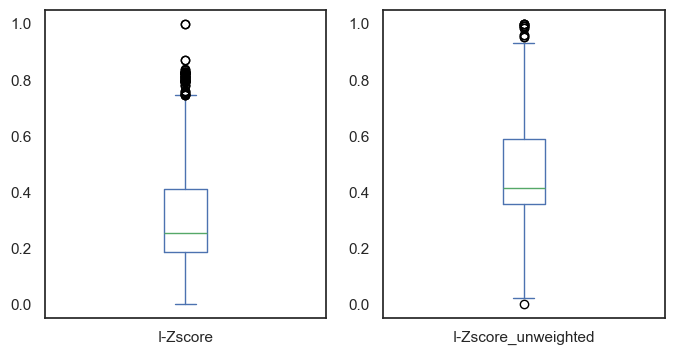

In [17]:
#check final distribution
Indexv4[['I-Zscore', 'I-Zscore_unweighted']].plot(kind='box', subplots=True, layout=(1, 2), figsize=(8, 4))

In [18]:
# Save it
# Convertir maxspeed en numérique (force les erreurs à NaN)
Indexv4['maxspeed'] = pd.to_numeric(Indexv4['maxspeed'], errors='coerce')


Indexv4.to_crs(target_crs).to_csv(f'{output_step3_path}/step3_index.csv', index = False)
Indexv4.to_crs(target_crs).to_parquet(f'{output_step3_path}/step3_index.parquet')
Indexv4.to_crs(target_crs).to_file(os.path.join(output_step3_path, "step3_features.gpkg"), driver="GPKG")

#After saving, perform a join-by-field value in QGIS with the shapefiles of the street segments. Join using the fields called "ID"